## MLP on MNIST — 多层感知机手写数字识别

### 什么是 MLP？

MLP（Multi-Layer Perceptron，多层感知机）是最基础的神经网络。它由多个**全连接层**堆叠而成：

```
输入(784维) → 全连接层(512) → BatchNorm → ReLU → Dropout
            → 全连接层(256) → BatchNorm → ReLU → Dropout
            → 全连接层(10) → 输出(logits)
```

### 本 Notebook 做什么？

从零开始定义一个 MLP 并在 MNIST 上训练，完整展示 **PyTorch 训练循环的 5 个核心步骤**：

```
① 清零梯度 → ② 前向传播 → ③ 计算损失 → ④ 反向传播 → ⑤ 更新参数
```

> 预期结果：约 537K 参数的 MLP 能达到 **~98.6%** 测试准确率。

## 1. 导入依赖与数据准备

导入 PyTorch 核心模块，自动检测 GPU。MNIST 数据从 OpenML 加载，独立运行无需依赖其他 notebook。

In [1]:
# [1.1 导入依赖]
# nn: 网络层 | optim: 优化器+调度器 | device: 自动选择 GPU/CPU
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
import warnings
warnings.filterwarnings('ignore')

# ==== 中文字体配置 ====
# matplotlib 默认不支持中文，需手动指定支持中文的字体
# 优先级：微软雅黑 > 黑体 > DejaVu Sans（英文回退）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 防止负号显示为方块

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# 自动选择可用设备：GPU 优先，无 GPU 则 CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'设备: {device}')

设备: cuda


In [5]:
# [1.2 加载 MNIST 数据]
# 此 cell 确保 notebook 可独立运行，无需依赖 01_data_exploration
# MNIST 共 70000 张 28×28 灰度图，前 60000 为训练集，后 10000 为测试集
mnist = fetch_openml(
    name="mnist_784", version=1, as_frame=False,
    cache=True, data_home="../data"
)
print(mnist.data[0].shape)
X = mnist.data.reshape(-1, 28, 28).astype(np.uint8)
print(X[0].shape)
y = mnist.target.astype(np.uint8)
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

# MLP 需要展平输入：28×28 → 784 维向量
# 同时归一化到 [0,1]
X_train_t = torch.tensor(X_train.reshape(-1, 784), dtype=torch.float32) / 255.0
X_test_t  = torch.tensor(X_test.reshape(-1, 784),  dtype=torch.float32) / 255.0
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

# ======== 超参数集中修改区 ========
BATCH_SIZE = 64
# =================================

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=BATCH_SIZE, shuffle=False)

print(f'训练批次数: {len(train_loader)}, 测试批次数: {len(test_loader)}')
print(f'输入形状: {X_train_t.shape} — 60000 个样本，每个 784 维')

(784,)
(28, 28)
训练批次数: 938, 测试批次数: 157
输入形状: torch.Size([60000, 784]) — 60000 个样本，每个 784 维


## 2. 定义 MLP 模型

### 网络结构

```
输入层 (784 维向量)
    │     ← 28×28 图片被"拉直"
    ▼
全连接层 512 + BatchNorm1d + ReLU + Dropout(0.2)
    │     ← 512 个神经元，每个连接前一层所有 784 个输入
    ▼
全连接层 256 + BatchNorm1d + ReLU + Dropout(0.2)
    │     ← 256 个神经元
    ▼
输出层 (10 维) ──► CrossEntropyLoss
         ← 10 个分数，分别对应数字 0~9
```

### 各组件的作用

| 组件 | 作用 | 通俗理解 |
|------|------|----------|
| `nn.Linear(784, 512)` | 线性变换 `y = Wx + b` | 每个输出是 784 个输入的加权求和 |
| `nn.BatchNorm1d(512)` | 批归一化 | 把数据"压"到均值 0 方差 1，让训练更稳定 |
| `nn.ReLU()` | 激活函数 `max(0, x)` | 负值变 0，引入非线性。没有它，100 层等于 1 层 |
| `nn.Dropout(0.2)` | 随机丢弃 20% 神经元 | 强迫网络不依赖特定路径，防止"死记硬背" |

> **为什么不在模型中加 Softmax？** `CrossEntropyLoss` 内置了 LogSoftmax，如果在模型里先做 Softmax 再取 log，数值精度会下降。

In [1]:
# [2. MLP 模型定义]
class MLP(nn.Module):
    """
    多层感知机 — 用于 MNIST 手写数字分类

    结构：
        Linear(784, 512) → BN → ReLU → Dropout(0.2)
        → Linear(512, 256) → BN → ReLU → Dropout(0.2)
        → Linear(256, 10)

    参数说明：
        input_dim:    输入维度，MNIST 展平为 784
        hidden_dims:  隐藏层维度列表，默认 [512, 256]
        num_classes:  分类数，MNIST 为 10
        dropout:      Dropout 比率，默认 0.2

    注意：
        输出是 logits（未经过 Softmax），因为 CrossEntropyLoss 内置了 Softmax
    """
    def __init__(self, input_dim=784, hidden_dims=None, num_classes=10, dropout=0.2):
        super(MLP, self).__init__()
        if hidden_dims is None:
            hidden_dims = [512, 256]

        # ==== 逐层构建全连接 Block ====
        # 每个 Block = Linear → BatchNorm → ReLU → Dropout
        # 用 prev_dim 追踪当前输入维度，动态连接各层
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))       # y = Wx + b，权重矩阵 (prev_dim×h_dim)
            layers.append(nn.BatchNorm1d(h_dim))            # 批归一化: 稳定训练，加速收敛
            layers.append(nn.ReLU())                        # 非线性激活: max(0,x)，引入非线性
            layers.append(nn.Dropout(dropout))              # 随机失活: 每次前向随机丢弃 dropout 比例的神经元
            prev_dim = h_dim

        # ==== 输出层 ====
        # 不加 BN（不需要）、不加 ReLU（logits 可为负）、不加 Dropout（输出层不需正则）
        layers.append(nn.Linear(prev_dim, num_classes))     # (256 → 10)
        self.net = nn.Sequential(*layers)  # Sequential 自动按顺序执行各层

    def forward(self, x):
        # 1. 兼容性处理: 图像格式 (B,1,28,28) 自动展平为 (B,784)
        if x.dim() == 4:
            x = x.view(x.size(0), -1)     # 保留 batch_size, 其余维展平
        # 2. 通过所有层: (B,784) → (B,512) → (B,256) → (B,10) logits
        return self.net(x)


# 实例化模型
model = MLP(input_dim=784, hidden_dims=[512, 256], num_classes=10, dropout=0.2).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'总参数量: {total_params:,}')
print(f'可训练参数量: {trainable_params:,}')
print()
print(model)

NameError: name 'nn' is not defined

## 3. 损失函数与优化器

### 为什么选 Adam？

- **Adam**：自适应学习率，对超参数不敏感，初学者首选。内置 Momentum + RMSProp
- **ReduceLROnPlateau**：当验证 loss 不再下降时，自动将学习率减半。避免在最优解附近"震荡"
- **Weight Decay=1e-4**：L2 正则化，限制权重大小，防止过拟合

> 对比：CNN/ResNet 通常用 SGD+Momentum（泛化更好），MLP 用 Adam 更稳定。

In [14]:
# [3. 损失函数 + 优化器 + 学习率调度器]
# Adam + ReduceLROnPlateau：适合 MLP 的稳定训练配置

# ======== 超参数集中修改区 ========
LR = 0.001
WEIGHT_DECAY = 1e-4
SCHEDULER_FACTOR = 0.5      # 学习率衰减倍率
SCHEDULER_PATIENCE = 5      # 连续 N 轮不降则衰减
# =================================

criterion = nn.CrossEntropyLoss()        # 交叉熵损失，内置 softmax
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# 学习率调度器：监控验证损失，连续 patience 轮不降则 lr *= factor
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=SCHEDULER_FACTOR,
    patience=SCHEDULER_PATIENCE, verbose=True
)

print(f'优化器: Adam(lr={LR}, weight_decay={WEIGHT_DECAY})')
print(f'调度器: ReduceLROnPlateau(factor={SCHEDULER_FACTOR}, patience={SCHEDULER_PATIENCE})')

优化器: Adam(lr=0.001, weight_decay=0.0001)
调度器: ReduceLROnPlateau(factor=0.5, patience=5)


## 4. 训练与评估函数

| 模式 | 调用 | 行为 |
|------|------|------|
| 训练 | `model.train()` | Dropout 生效，BatchNorm 实时统计 |
| 评估 | `model.eval()` + `torch.no_grad()` | Dropout 关闭，BN 冻结，不计算梯度 |

In [15]:
# [4. 训练/评估函数]
def train_one_epoch(model, loader, criterion, optimizer, device):
    """训练一个 epoch，返回 (avg_loss, accuracy)"""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        # 标准训练五步：清零 → 前向 → 损失 → 反向 → 更新
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """评估模型，返回 (avg_loss, accuracy)"""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

## 5. 启动训练

训练 20 个 epoch。每个 epoch 后调用 `scheduler.step(test_loss)` 监控验证损失并调整学习率。
自动保存最佳模型（`best.pth`）和周期性 checkpoint。

> 预期训练时间：CPU 约 3~5 分钟，GPU 约 30 秒。

In [16]:
# [5. 训练循环]
# ======== 超参数集中修改区 ========
EPOCHS = 20
CHECKPOINT_INTERVAL = 20
SAVE_DIR = '../models/mlp'
# =================================

history = {
    'train_loss': [], 'train_acc': [],
    'test_loss': [],  'test_acc': []
}

best_test_acc = 0.0
best_epoch = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    test_loss, test_acc = evaluate(
        model, test_loader, criterion, device
    )
    scheduler.step(test_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch
        torch.save(model.state_dict(), f'{SAVE_DIR}/best.pth')

    if epoch % CHECKPOINT_INTERVAL == 0:
        torch.save(model.state_dict(), f'{SAVE_DIR}/epoch_{epoch}.pth')
        print(f'  [checkpoint] mlp_epoch_{epoch}.pth')

    if epoch % 5 == 0 or epoch == 1:
        print(
            f'Epoch [{epoch:3d}/{EPOCHS}] '
            f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
            f'Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.4f}'
        )

print(f'\n训练完成！最佳测试准确率: {best_test_acc:.4f} (Epoch {best_epoch})')

Epoch [  1/20] Train Loss: 0.2021 | Train Acc: 0.9399 | Test Loss:  0.0915 | Test Acc:  0.9718
Epoch [  5/20] Train Loss: 0.0638 | Train Acc: 0.9800 | Test Loss:  0.0681 | Test Acc:  0.9781
Epoch [ 10/20] Train Loss: 0.0516 | Train Acc: 0.9831 | Test Loss:  0.0556 | Test Acc:  0.9828
Epoch [ 15/20] Train Loss: 0.0439 | Train Acc: 0.9852 | Test Loss:  0.0622 | Test Acc:  0.9806
  [checkpoint] mlp_epoch_20.pth
Epoch [ 20/20] Train Loss: 0.0214 | Train Acc: 0.9932 | Test Loss:  0.0505 | Test Acc:  0.9839

训练完成！最佳测试准确率: 0.9851 (Epoch 18)


## 6. 训练曲线可视化

左侧 Loss 曲线观察收敛情况，右侧 Accuracy 曲线用虚线标出最佳准确率。

### 如何判断过拟合？

看 Train Loss 和 Test Loss 的差距：
- **差距小** → 模型泛化好
- **Train Loss 持续下降但 Test Loss 上升** → 过拟合（模型在"背诵"训练集）
- MLP 通常 train-test gap 约 1%，属于正常范围

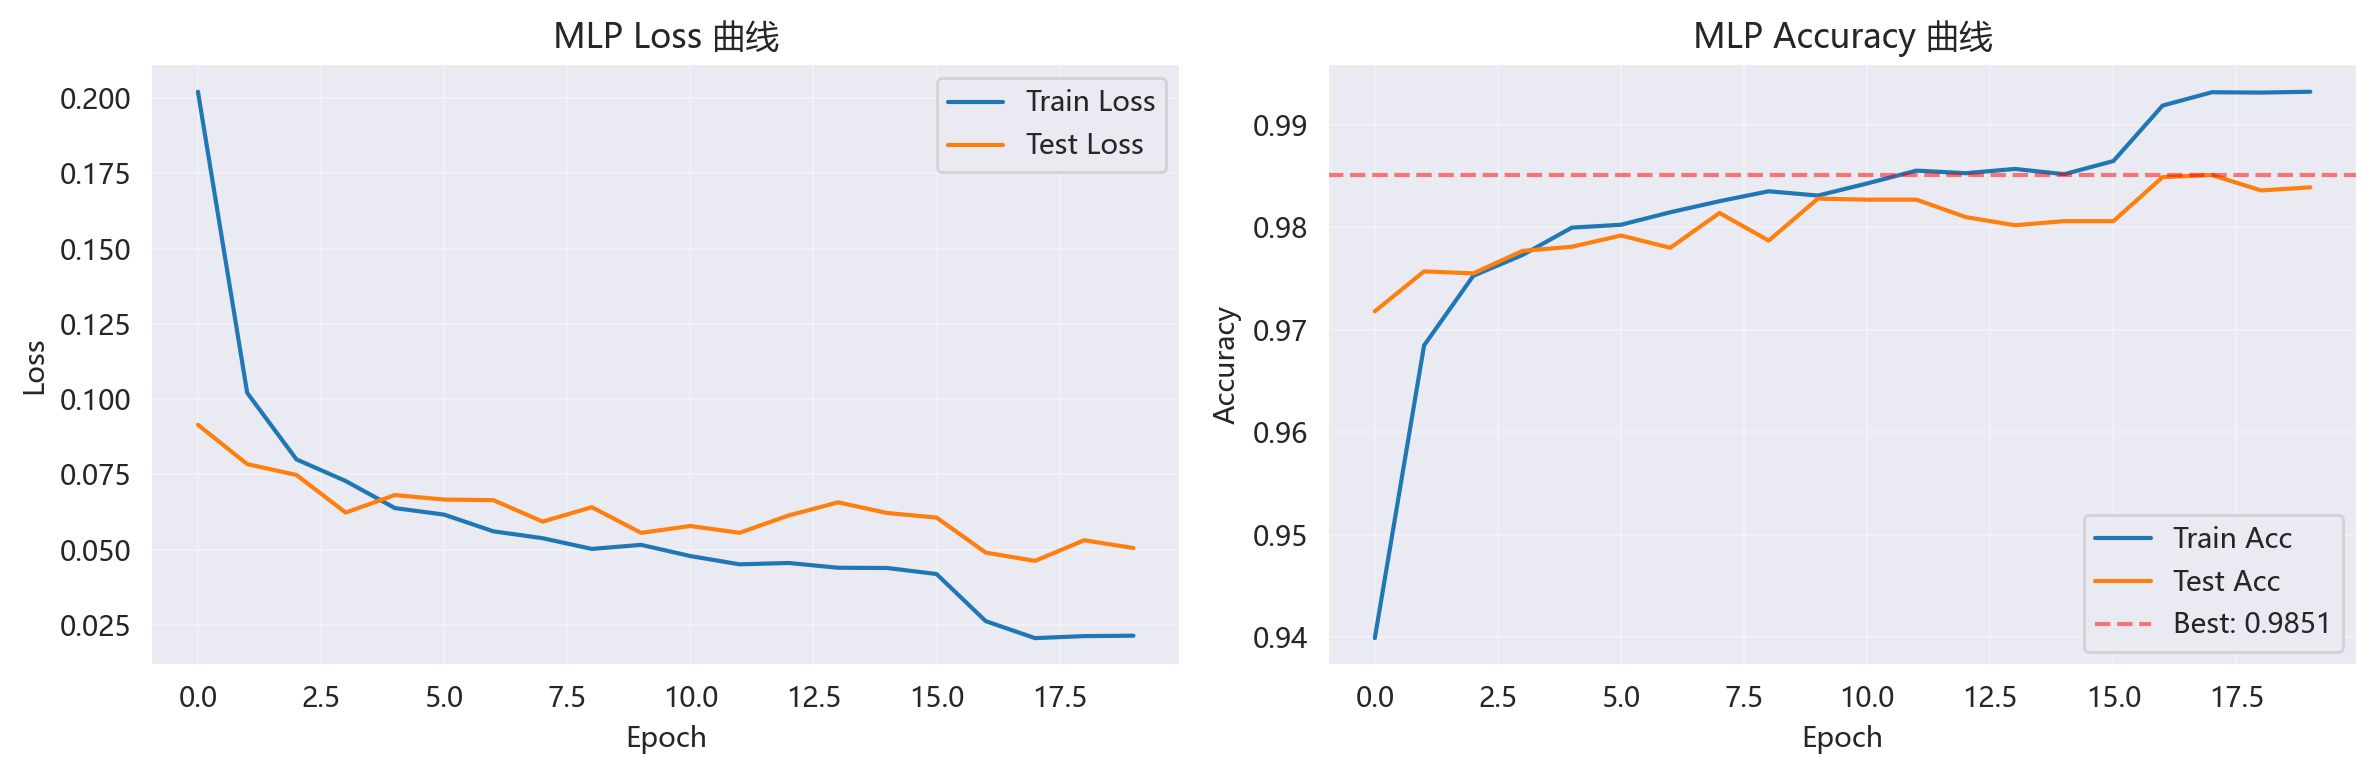

In [17]:
# [6. 训练曲线可视化]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['test_loss'], label='Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('MLP Loss 曲线')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['test_acc'], label='Test Acc')
axes[1].axhline(y=best_test_acc, color='r', linestyle='--', alpha=0.5,
                label=f'Best: {best_test_acc:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('MLP Accuracy 曲线')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 进一步学习

1. 修改 `hidden_dims` 尝试不同网络深度和宽度
2. 对比 [05_cnn_mnist.ipynb](05_cnn_mnist.ipynb)，看 CNN 如何用更少参数达到更好效果
3. 进入 [03_evaluation.ipynb](03_evaluation.ipynb) 学习如何评估和分析模型